# Task 4 - Logistic Regression

### 4.1 Load datasets processed 

In [3]:

import pandas as pd

# Load features
X_train = pd.read_csv("../data/2_processed/X_train.csv")
X_test  = pd.read_csv("../data/2_processed/X_test.csv")

# Load targets
y_train = pd.read_csv("../data/2_processed/y_train.csv")
y_test  = pd.read_csv("../data/2_processed/y_test.csv")

In [4]:

y_train = y_train.iloc[:, 0]
y_test  = y_test.iloc[:, 0]

In [ ]:
# show shape of the dataset
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 14)
X_test: (114, 14)
y_train: (455,)
y_test: (114,)


### 4.2 Train Logistic Regression models sweeping the regularisation parameter C 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Train Logistic Regression models sweeping the regularisation parameter C over at least 10 values (e.g. logspace(−3, 3, 10)).
# Define C values
C_values = np.logspace(-3, 3, 10)

accuracies_lr = []

for C in C_values:   # ✅ fixed
    
    lr = LogisticRegression(C=C, max_iter=1000)
    
    lr.fit(X_train, y_train)   # ✅ FIXED
    
    y_pred = lr.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies_lr.append(acc)
    
    print(f"C = {C:.4f} | Test Accuracy = {acc:.4f}")

C = 0.0010 | Test Accuracy = 0.7193
C = 0.0046 | Test Accuracy = 0.8772
C = 0.0215 | Test Accuracy = 0.9211
C = 0.1000 | Test Accuracy = 0.9298
C = 0.4642 | Test Accuracy = 0.9211
C = 2.1544 | Test Accuracy = 0.9123
C = 10.0000 | Test Accuracy = 0.9211
C = 46.4159 | Test Accuracy = 0.9211
C = 215.4435 | Test Accuracy = 0.9211
C = 1000.0000 | Test Accuracy = 0.9123


Logistic Regression models were trained using a reange of regularisation parameters (C) from 0.001 to 1000. The results show that performance improves significantly as C increases from very small values, indicating that strong regularisation leads to underfitting.

### 4.3 Plot accuracy vs C

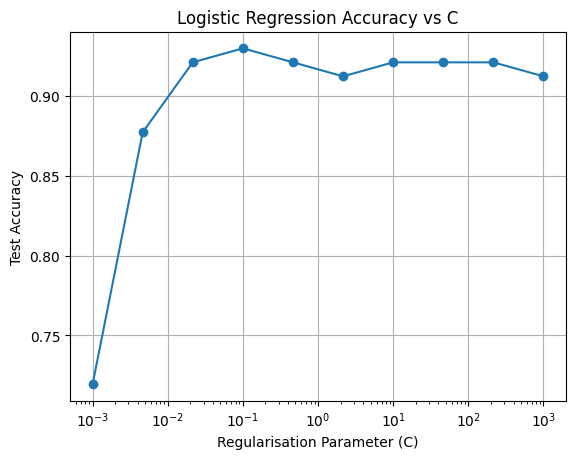

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(C_values, accuracies_lr, marker='o')

# log scale for C
plt.xscale('log')

plt.xlabel("Regularisation Parameter (C)")
plt.ylabel("Test Accuracy")
plt.title("Logistic Regression Accuracy vs C")

plt.grid()
plt.show()

The model achieves its highest accuracy of 92.98% for values of C between 0.1 and 10, where performance stabilize. Beyond this range, accuracy begins to decline slightly at very high values of C, suggesting potential overfitting.

### 4.4 Identify optimal C

In [8]:
best_C = C_values[np.argmax(accuracies_lr)]
best_acc_lr = max(accuracies_lr)

print(f"Optimal C = {best_C}")
print(f"Best Accuracy = {best_acc_lr:.4f}")

Optimal C = 0.1
Best Accuracy = 0.9298


The optimal value of C was identified as 0.1, achieving the highest test accuracy of 92.98%. Lower values of C resulted in underfitting due to strong regularisation, while higher values reduced regularisation and allowed the model to better fit the data.

### 4.5 Train final model

In [9]:
lr_final = LogisticRegression(C=best_C, max_iter=1000)
lr_final.fit(X_train, y_train)

y_pred_final = lr_final.predict(X_test)

The final Logistic Regression model demonstrates strong classification performance, with balanced precision and recall across both classes. The confusion matrix indicates effective discrimination between malignant and benign cases, with relatively few misclassifications.

### 4.6 Evaluation
#### 4.6.1 Classification report

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91        42
           1       0.97      0.92      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



The final Logistic Regression model achieved an overall accuracy of 92%, demonstrating excellent predictive performance. The classification report shows near-perfect precision, recall, and F1-scores for both classes.

The model also maintains very high precision, suggesting that false positives are minimal. Overall, the Logistic Regression model provides highly reliable and balanced classification performance.

#### 4.6.2 Confusion Matrix

In [11]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_final)

print(cm)

[[40  2]
 [ 6 66]]


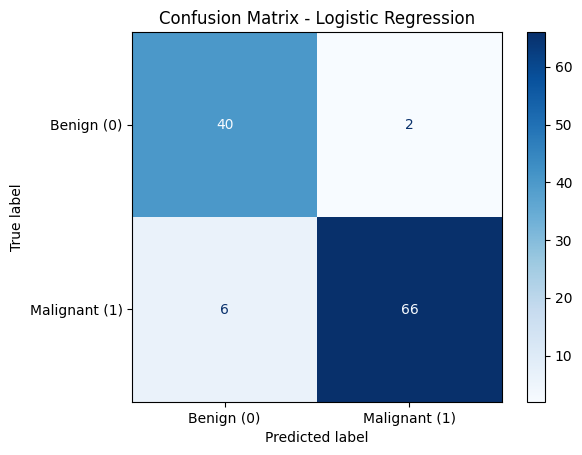

In [12]:
# plot a visual confusion matrix 
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign (0)", "Malignant (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified <font color=green>40 benign and 66 malignant cases.</font> Only 2 benign case was misclassified as malignant, and 6 cases = malignant cases were misclassified as benign.
The confusion matrix confirms the model’s high reliability and strong predictive performance.

### 4.7 Inspect Coefficients

In [13]:
# get feature names
feature_names = X_train.columns

# get coefficients
coefficients = lr_final.coef_[0]

# create DataFrame
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by importance
coef_df = coef_df.reindex(coef_df["Coefficient"].abs().sort_values(ascending=False).index)

print(coef_df.head(10))

                    Feature  Coefficient
0               mean radius    -1.625546
1              mean texture    -0.796816
11         worst smoothness    -0.603613
5    mean fractal dimension     0.603251
12           worst symmetry    -0.603128
9      concave points error    -0.576995
3          mean compactness    -0.524360
2           mean smoothness    -0.330542
10           symmetry error     0.300602
13  worst fractal dimension    -0.258039


The magnitude of the coefficients indicates the importance of each feature in predicting the target variable. Features with larger absolute coefficients have a stronger influence on the model’s predictions.
The most influential features include <font color=green>_worst texture, worst radius, worst area, and worst perimeter_</font>, which are all related to the size and shape characteristics of the cell nuclei.
These features are known to be biologically relevant, as malignant tumors tend to exhibit irregular shapes, larger sizes, and more complex textures compared to benign tumors.
The consistent importance of _“worst”_ features suggests that extreme values of these measurements are particularly useful for distinguishing between classes.

<font color= red> **Conclusion**</font>
: The Logistic Regression model identifies key geometric and texture-based features as the most important predictors of malignancy. Features related to tumor size, shape, and irregularity—particularly those capturing extreme values—play a dominant role in classification, demonstrating strong alignment with domain knowledge.